## Denoising Diffusion Probabilistic Model (DDPM)

Using device: cuda
Epoch [1/75] Step [0/469] Loss: 1.13511 LR: 0.000040
Epoch [1/75] Step [100/469] Loss: 0.94238 LR: 0.000040
Epoch [1/75] Step [200/469] Loss: 0.76982 LR: 0.000041
Epoch [1/75] Step [300/469] Loss: 0.63285 LR: 0.000043
Epoch [1/75] Step [400/469] Loss: 0.51169 LR: 0.000045
Epoch 1 finished - average loss: 0.75034
Epoch [2/75] Step [0/469] Loss: 0.47398 LR: 0.000047
Epoch [2/75] Step [100/469] Loss: 0.42338 LR: 0.000050
Epoch [2/75] Step [200/469] Loss: 0.37239 LR: 0.000054
Epoch [2/75] Step [300/469] Loss: 0.32545 LR: 0.000058
Epoch [2/75] Step [400/469] Loss: 0.28493 LR: 0.000063
Epoch 2 finished - average loss: 0.36543
Epoch [3/75] Step [0/469] Loss: 0.28315 LR: 0.000067
Epoch [3/75] Step [100/469] Loss: 0.26056 LR: 0.000073
Epoch [3/75] Step [200/469] Loss: 0.21785 LR: 0.000079
Epoch [3/75] Step [300/469] Loss: 0.20023 LR: 0.000086
Epoch [3/75] Step [400/469] Loss: 0.19756 LR: 0.000094
Epoch 3 finished - average loss: 0.22812
Epoch [4/75] Step [0/469] Loss: 0.20109

Sampling: 100%|██████████| 1000/1000 [00:18<00:00, 55.09it/s]


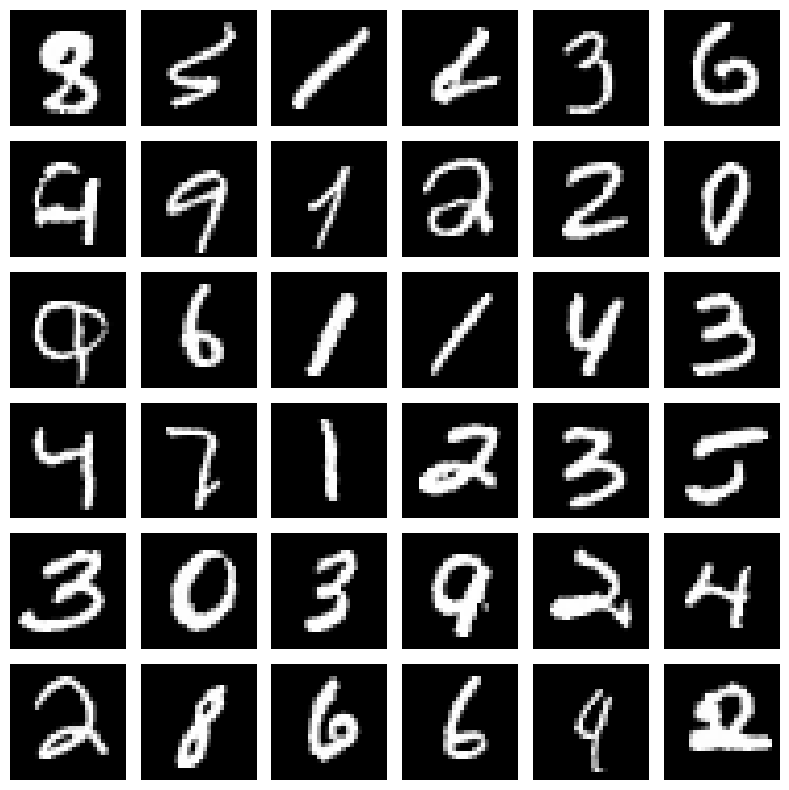

In [4]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

from model import MNISTDiffusion
from utils import ExponentialMovingAverage


# =========================
# 1) Config
# =========================
class Config:
    lr = 1e-3
    batch_size = 128
    epochs = 75
    n_samples = 36
    model_base_dim = 64
    timesteps = 1000
    model_ema_steps = 10
    model_ema_decay = 0.995
    log_freq = 100
    no_clip = False
    image_size = 28
    num_workers = 2


# =========================
# 2) Data loader
# =========================
def create_mnist_dataloader(batch_size, image_size=28, num_workers=2):
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))   # [0,1] -> [-1,1]
    ])

    train_dataset = MNIST(
        root="./mnist_data",
        train=True,
        download=True,
        transform=transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader


# =========================
# 3) Plotting helper
# =========================
def show_images(images, nrow=6, figsize=(8, 8)):
    """
    images: tensor of shape (N, 1, H, W), assumed in [-1, 1]
    """
    images = images.detach().cpu()
    images = (images + 1) / 2.0          # back to [0,1]
    images = images.clamp(0, 1)

    n_images = images.shape[0]
    ncol = nrow
    nrows = math.ceil(n_images / ncol)

    fig, axes = plt.subplots(nrows, ncol, figsize=figsize)
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for i in range(len(axes)):
        axes[i].axis("off")
        if i < n_images:
            axes[i].imshow(images[i, 0], cmap="gray")

    plt.tight_layout()
    plt.show()


# =========================
# 4) Training function
# =========================
def train_mnist_diffusion(cfg):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Using device:", device)

    train_loader = create_mnist_dataloader(
        batch_size=cfg.batch_size,
        image_size=cfg.image_size,
        num_workers=cfg.num_workers
    )

    model = MNISTDiffusion(
        timesteps=cfg.timesteps,
        image_size=cfg.image_size,
        in_channels=1,
        base_dim=cfg.model_base_dim,
        dim_mults=[2, 4]
    ).to(device)

    # EMA
    adjust = cfg.batch_size * cfg.model_ema_steps / cfg.epochs
    alpha = 1.0 - cfg.model_ema_decay
    alpha = min(1.0, alpha * adjust)
    model_ema = ExponentialMovingAverage(model, device=device, decay=1.0 - alpha)

    optimizer = AdamW(model.parameters(), lr=cfg.lr)
    scheduler = OneCycleLR(
        optimizer,
        max_lr=cfg.lr,
        total_steps=cfg.epochs * len(train_loader),
        pct_start=0.25,
        anneal_strategy="cos"
    )

    loss_fn = nn.MSELoss(reduction="mean")
    global_steps = 0

    for epoch in range(cfg.epochs):
        model.train()
        epoch_loss = 0.0

        for step, (images, _) in enumerate(train_loader):
            images = images.to(device)
            noise = torch.randn_like(images)

            optimizer.zero_grad()

            pred_noise = model(images, noise)
            loss = loss_fn(pred_noise, noise)

            loss.backward()
            optimizer.step()
            scheduler.step()

            if global_steps % cfg.model_ema_steps == 0:
                model_ema.update_parameters(model)

            global_steps += 1
            epoch_loss += loss.item()

            if step % cfg.log_freq == 0:
                print(
                    f"Epoch [{epoch+1}/{cfg.epochs}] "
                    f"Step [{step}/{len(train_loader)}] "
                    f"Loss: {loss.item():.5f} "
                    f"LR: {scheduler.get_last_lr()[0]:.6f}"
                )

        avg_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch+1} finished - average loss: {avg_loss:.5f}")

    return model, model_ema


# =========================
# 5) Sampling function
# =========================
@torch.no_grad()
def generate_images(model_ema, n_samples=36, no_clip=False):
    device = next(model_ema.module.parameters()).device
    model_ema.eval()

    samples = model_ema.module.sampling(
        n_samples,
        clipped_reverse_diffusion=not no_clip,
        device=device
    )
    return samples


# =========================
# 6) Run everything
# =========================
cfg = Config()

model, model_ema = train_mnist_diffusion(cfg)
samples = generate_images(model_ema, n_samples=cfg.n_samples, no_clip=cfg.no_clip)
show_images(samples, nrow=int(math.sqrt(cfg.n_samples)))